# Package

In [1]:
# ============================================================
# 1) Core Python & Paths
# ============================================================
import sys
from pathlib import Path
from tempfile import TemporaryDirectory
from dataclasses import dataclass
from typing import Callable, Dict, Any, Optional, List, Iterable

from dateutil.relativedelta import relativedelta

# Project root (notebook dans /notebooks)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# 2) Scientific Stack (NumPy / Pandas)
# ============================================================
import numpy as np
import pandas as pd


# ============================================================
# 3) Machine Learning & Models
# ============================================================
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    ParameterSampler
)

from lightgbm import LGBMRegressor


# ============================================================
# 4) Forecasting (Nixtla MLForecast)
# ============================================================
from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals


# ============================================================
# 5) Data & Project Utilities
# ============================================================
from utils import load_wide_from_feast, build_unrate_exog_dataset

# ============================================================
# 6) Statistical Tests
# ============================================================
from scipy.stats import ttest_rel
from statsmodels.stats.contingency_tables import mcnemar


# ============================================================
# 7) Visualization
# ============================================================
from utilsforecast.plotting import plot_series
from IPython.display import IFrame, display

# ============================================================
# 8) Experiment Tracking (MLflow)
# ============================================================
import mlflow
from mlflow.tracking import MlflowClient

# Importation des données

In [2]:
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

START = "1960-01-01"
END   = "2025-08-01"

In [3]:
# ============================================================
# 1) WIDE dataset (df) depuis Feast
# ============================================================

LAG = 12  

df = load_wide_from_feast(
    "stationary_value:value",
    series_ids,
    start=START,
    end=END
)

# ============================================================
# 2) Convert WIDE -> LONG (obligatoire pour build_unrate_exog_dataset)
# ============================================================
df_stationary = (
    df.reset_index()
      .melt(id_vars="date", var_name="series_id", value_name="value")
)

# ============================================================
# 3) Build target + exog + MLForecast format
# ============================================================
df_model, ts_lr, exog_cols = build_unrate_exog_dataset(df_stationary)

# ============================================================
# 4) ✅ TOUTES les exog laggées de 12 mois (aucune contemporaine)
#    - on crée BUSLOANS_lag12, CPIAUCSL_lag12, ...
#    - on supprime BUSLOANS, CPIAUCSL, ... (contemporaines)
# ============================================================
ts_lr = ts_lr.sort_values(["unique_id", "ds"]).copy()

exog_cols_lag12 = []
for c in exog_cols:
    new_c = f"{c}_lag{LAG}"
    ts_lr[new_c] = ts_lr.groupby("unique_id")[c].shift(LAG)
    exog_cols_lag12.append(new_c)

# supprimer les exog contemporaines
ts_lr = ts_lr.drop(columns=exog_cols)

# mettre à jour la liste exog utilisée par MLForecast
exog_cols = exog_cols_lag12

# drop lignes où les lag12 n'existent pas (12 premiers mois)
ts_lr = ts_lr.dropna(subset=["y"] + exog_cols).reset_index(drop=True)

# ============================================================
# 5) Prints / checks
# ============================================================
print("df (wide) shape:", df.shape)
print("df_stationary (long) shape:", df_stationary.shape)
print("df_model shape:", df_model.shape)
print("ts_lr shape (after lag12):", ts_lr.shape)
print("Exog cols (lag12):", exog_cols)

print("\nPreview:")
print(ts_lr[["unique_id", "ds", "y"] + exog_cols[:5]].head(15))

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.
df (wide) shape: (788, 11)
df_stationary (long) shape: (8668, 3)
df_model shape: (788, 12)
ts_lr shape (after lag12): (776, 13)
Exog cols (lag12): ['BUSLOANS_lag12', 'CPIAUCSL_lag12', 'DPCERA3M086SBEA_lag12', 'INDPRO_lag12', 'M2SL_lag12', 'OILPRICEX_lag12', 'RPI_lag12', 'SP500_lag12', 'TB3MS_lag12', 'USREC_lag12']

Preview:
   unique_id         ds    y  BUSLOANS_lag12  CPIAUCSL_lag12  \
0     UNRATE 1961-01-01  1.4        0.011578       -0.006156   
1     UNRATE 1961-02-01  2.1        0.011905       -0.003767   
2     UNRATE 1961-03-01  1.5       -0.008356       -0.005455   
3     UNRATE 1961-04-01  1.8       -0.009098        0.005090   
4     UNRATE 1961-05-01  2.0       -0.000359        0.003383   
5     UNRATE 1961-06-01  1.5        0.014620        0.006777   
6     UNRATE 1961-07-01  1.5       -0.000611       -0.005433   
7     UNRATE 1961-08-01  1.0       -0.016888       -0.004074   

d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ML Experiment\utils.py:148: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  idx = idx.to_period("M").to_timestamp(how="start").normalize()


# Model settings

In [4]:

# -----------------------------
# Helpers temps
# -----------------------------
def _ensure_ms(x):
    x = pd.Timestamp(x)
    return x.to_period("M").to_timestamp(how="start").normalize()

def _n_windows_monthly(ds_start, ds_end):
    return (ds_end.year - ds_start.year) * 12 + (ds_end.month - ds_start.month) + 1

def _slice_cv_block(ts, cutoff_start, n_windows, h):
    cutoff_end = cutoff_start + relativedelta(months=n_windows - 1)
    ds_end = cutoff_end + relativedelta(months=h)
    return ts[ts["ds"] <= ds_end].copy(), cutoff_end, ds_end

In [ ]:
# -----------------------------
# Spec modèle 
# -----------------------------
@dataclass
class ModelSpec:
    name: str                         #
    build_mlf: Callable[[str, Dict[str, Any]], MLForecast]  # (freq, params)->MLForecast
    pred_col: str                     # colonne de forecast dans cv (ex "LR")
    tunable: bool = False
    param_space: Optional[Dict[str, Iterable[Any]]] = None
    search: str = "random"            # "random"|"grid"
    n_iter: int = 50                  # si random
    tune_cv_windows: int = 6
    tune_every_months: int = 36
    use_conformal_in_tune: bool = False
    fixed_params: Optional[Dict[str, Any]] = None

In [6]:
# -----------------------------
# Tuner générique (pour tous les modèles)
# -----------------------------
def _tune_on_train(
    ts_train: pd.DataFrame,
    *,
    spec: ModelSpec,
    freq: str,
    h: int,
    levels: List[int],
    seed: int,
    pi_windows_cap: int,
    min_train_n: Optional[int] = None,
) -> tuple[Optional[Dict[str, Any]], float]:

    if min_train_n is not None and len(ts_train) < int(min_train_n):
        return None, float("nan")

    if not spec.tunable:
        return (spec.fixed_params or {}), float("nan")

    if not spec.param_space:
        raise ValueError(f"{spec.name}: tunable=True mais param_space=None")

    # conformal au tuning (souvent OFF)
    pi_tune = (
        PredictionIntervals(h=h, n_windows=min(int(spec.tune_cv_windows), int(pi_windows_cap)),
                            method="conformal_distribution")
        if spec.use_conformal_in_tune else None
    )

    # générateur d'essais
    if spec.search == "grid":
        sampler = ParameterGrid(spec.param_space)
    else:
        sampler = ParameterSampler(spec.param_space, n_iter=int(spec.n_iter), random_state=int(seed))

    best_params = None
    best_score = np.inf

    for params in sampler:
        params = dict(params)

        mlf = spec.build_mlf(freq, params)
        cv = mlf.cross_validation(
            df=ts_train,
            h=h,
            step_size=1,
            n_windows=int(spec.tune_cv_windows),
            prediction_intervals=pi_tune,
            level=list(levels) if pi_tune is not None else None,
            fitted=False,
            static_features=[],
            dropna=True,
        )
        score = mean_absolute_error(cv["y"], cv[spec.pred_col])

        if score < best_score:
            best_score = float(score)
            best_params = params

    return best_params, float(best_score)


In [7]:
# -----------------------------
# Runner multi-modèles : tu ajoutes juste un spec dans la liste
# -----------------------------
def run_backtesting_generic(
    ts: pd.DataFrame,
    *,
    model_specs: List[ModelSpec],
    freq: str,
    h: int,
    exp_start,
    exp_end,
    step_size: int,
    pi_windows: int,
    levels: List[int],
    seed: int = 0,
    min_train_n: Optional[int] = None,
) -> tuple[pd.DataFrame, Dict[str, Any]]:

    # run modèle par modèle puis merge
    bkts = []
    metas = {}
    bundles = {}   # ✅ NOUVEAU

    for spec in model_specs:
        bkt_m, meta_m = backtest_one_model_tune_blocks(
            ts,
            spec=spec,
            freq=freq,
            h=h,
            exp_start=exp_start,
            exp_end=exp_end,
            step_size=step_size,
            pi_windows=pi_windows,
            levels=levels,
            seed=seed,
            min_train_n=min_train_n,
        )
        metas[spec.name] = meta_m

        # ✅ NOUVEAU : bundle explicabilité (si dispo)
        fitted_models = meta_m.get("fitted_models", None)
        train_dates   = meta_m.get("train_fit_dates", None) or meta_m.get("train_periods", None)
        features      = meta_m.get("features", None)
        preprocs      = meta_m.get("preprocs", None)

        if isinstance(fitted_models, list) and len(fitted_models) > 0 and train_dates is not None and features is not None:
            bundles[spec.name] = {
                "models": fitted_models,
                "train_fit_dates": list(pd.to_datetime(pd.Index(train_dates))),
                "features": list(features),
                "preprocs": preprocs,
                "params": meta_m,   # pratique: tu gardes toute la meta
            }

        if len(bkt_m):
            bkts.append(bkt_m)

    if not bkts:
        return pd.DataFrame(), {"error": "aucun modèle n’a produit de backtest", "metas": metas, "bundles": bundles}

    # merge wide sur clés
    keys = ["unique_id", "ds", "cutoff", "y"]
    bkt_all = bkts[0].copy()

    for b in bkts[1:]:
        keep_cols = [c for c in b.columns if c not in bkt_all.columns or c in keys]
        bkt_all = bkt_all.merge(b[keep_cols], on=keys, how="outer")

    bkt_all = bkt_all.sort_values(["unique_id", "ds", "cutoff"]).reset_index(drop=True)

    # ✅ 1 ligne par ds : dernier cutoff
    bkt_final = (
        bkt_all.sort_values(["unique_id", "ds", "cutoff"])
               .groupby(["unique_id", "ds"], as_index=False)
               .tail(1)
               .reset_index(drop=True)
    )

    meta = {"metas": metas, "bundles": bundles}  # ✅ NOUVEAU
    return bkt_final, meta

In [8]:
def backtest_one_model_tune_blocks(
    ts: pd.DataFrame,
    *,
    spec: ModelSpec,
    freq: str,
    h: int,
    exp_start,
    exp_end,
    step_size: int,
    pi_windows: int,
    levels: List[int],
    seed: int = 0,
    min_train_n: Optional[int] = None,
) -> tuple[pd.DataFrame, Dict[str, Any]]:

    ts = ts.copy()
    ts["ds"] = (
        pd.to_datetime(ts["ds"], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )
    if ts["ds"].isna().any():
        bad = ts[ts["ds"].isna()].head()
        raise ValueError(f"Dates 'ds' invalides après parsing. Exemples:\n{bad}")

    exp_start = _ensure_ms(exp_start)
    exp_end   = _ensure_ms(exp_end)

    cutoff_start_all = exp_start - relativedelta(months=h)
    cutoff_end_all   = exp_end   - relativedelta(months=h)
    total_partitions = _n_windows_monthly(cutoff_start_all, cutoff_end_all)

    # anti-fuite
    ts = ts[ts["ds"] <= exp_end].copy()

    # conformal au backtest (ici ON)
    pi = PredictionIntervals(h=h, n_windows=int(pi_windows), method="conformal_distribution")

    # blocs de retrain/tuning
    blocks = []
    remaining = int(total_partitions)
    cur = cutoff_start_all
    while remaining > 0:
        n_win = min(int(spec.tune_every_months), remaining)
        blocks.append((cur, n_win))
        cur = cur + relativedelta(months=n_win)
        remaining -= n_win

    all_bkts = []
    params_history = []
    tune_history = []

    # ✅ explicabilité (sans refit) : on veut des modèles récupérables
    fitted_models: list = []
    train_fit_dates: list = []

    # colonnes candidates selon versions
    candidate_model_cols = ["fitted", "fitted_model", "model", "models", "forecaster", "estimator"]

    for block_idx, (cutoff_start_blk, n_windows_blk) in enumerate(blocks, start=1):
        ts_blk, _, _ = _slice_cv_block(ts, cutoff_start_blk, int(n_windows_blk), h)

        ts_train_for_tune = ts[ts["ds"] <= cutoff_start_blk].copy()
        if min_train_n is not None and len(ts_train_for_tune) < int(min_train_n):
            continue

        best_params, tune_mae = _tune_on_train(
            ts_train_for_tune,
            spec=spec,
            freq=freq,
            h=h,
            levels=levels,
            seed=seed,
            pi_windows_cap=int(pi_windows),
            min_train_n=min_train_n,
        )
        if best_params is None:
            continue

        params_history.append({
            "model": spec.name,
            "block": block_idx,
            "cutoff_start": cutoff_start_blk,
            "n_windows": int(n_windows_blk),
            **best_params,
        })
        tune_history.append({
            "model": spec.name,
            "block": block_idx,
            "cutoff_start": cutoff_start_blk,
            "tune_mae": float(tune_mae),
        })

        # --------- CV predictions (avec PI)
        mlf_blk = spec.build_mlf(freq, best_params)

        bkt_blk = mlf_blk.cross_validation(
            df=ts_blk,
            h=h,
            step_size=int(step_size),
            n_windows=int(n_windows_blk),
            prediction_intervals=pi,
            level=list(levels),
            fitted=True,
            static_features=[],
            dropna=True,
        )

        bkt_blk[f"{spec.name}_tune_block"] = block_idx
        bkt_blk[f"{spec.name}_tune_mae"] = float(tune_mae)

        # --------- DEBUG (tu peux laisser, ou enlever après)
        # print(f"[DEBUG {spec.name}] cols: {list(bkt_blk.columns)}")

        # --------- 1) Essai: récupérer modèles directement dans le DF (si colonne existe)
        col_found = next((c for c in candidate_model_cols if c in bkt_blk.columns), None)

        if col_found is not None:
            tmp_fit = (
                bkt_blk[["cutoff", col_found]]
                .dropna()
                .drop_duplicates("cutoff")
                .sort_values("cutoff")
            )
            fitted_models.extend(tmp_fit[col_found].tolist())
            train_fit_dates.extend(pd.to_datetime(tmp_fit["cutoff"]).tolist())

        else:
            # --------- 2) Fallback garanti: 1 modèle par bloc (fit sur ts_train_for_tune)
            # Utile si ta version MLForecast ne renvoie pas l'objet fitted dans le DataFrame
            mlf_fitted = spec.build_mlf(freq, best_params)
            mlf_fitted.fit(ts_train_for_tune, static_features=[])
            fitted_models.append(mlf_fitted)
            train_fit_dates.append(pd.to_datetime(cutoff_start_blk))

        all_bkts.append(bkt_blk)

    if not all_bkts:
        return pd.DataFrame(), {"error": f"{spec.name}: aucun bloc produit"}

    bkt = pd.concat(all_bkts, ignore_index=True)

    # filtre exp exact
    bkt = bkt[(bkt["ds"] >= exp_start) & (bkt["ds"] <= exp_end)].copy()
    bkt = bkt.sort_values(["unique_id", "ds", "cutoff"]).reset_index(drop=True)

    # features pour explicabilité
    _features = None
    if "exog_cols" in globals():
        try:
            _features = list(globals()["exog_cols"])
        except Exception:
            _features = None

    meta = dict(
        model=spec.name,
        h=int(h),
        step_size=int(step_size),
        exp_start=exp_start,
        exp_end=exp_end,
        cutoff_start=cutoff_start_all,
        cutoff_end=cutoff_end_all,
        partitions=int(total_partitions),
        pi_windows=int(pi_windows),
        tune_every_months=int(spec.tune_every_months),
        tune_cv_windows=int(spec.tune_cv_windows),
        tunable=bool(spec.tunable),
        search=spec.search,
        n_iter=int(spec.n_iter),
        use_conformal_in_tune=bool(spec.use_conformal_in_tune),
        param_space=spec.param_space,
        params_history=params_history,
        tune_history=tune_history,

        # ✅ bundle explicabilité
        fitted_models=fitted_models,
        train_fit_dates=train_fit_dates,
        features=_features,
        preprocs=None,
    )
    return bkt, meta

In [9]:
# ============================================================
# Builders modèles
# ============================================================

def build_lr(freq, params):
    return MLForecast(models={"LR": LinearRegression()}, freq=freq, lags=[], date_features=[])

def build_ridge(freq, params):
    alpha = params.get("alpha", 1.0)
    return MLForecast(models={"RIDGE": Ridge(alpha=alpha)}, freq=freq, lags=[], date_features=[])

LGBM_BASE = dict(random_state=0, n_jobs=-1, verbosity=-1, objective="regression", metric="mae")

def build_lgbm(freq, params):
    p = dict(LGBM_BASE)
    p.update(params)
    return MLForecast(models={"LGBM": LGBMRegressor(**p)}, freq=freq, lags=[], date_features=[])

# ============================================================
# Model Specs (LR + RIDGE + LGBM)
# ============================================================

MODEL_SPECS = [
    ModelSpec(
        name="LR",
        build_mlf=build_lr,
        pred_col="LR",
        tunable=False,
        fixed_params={},
    ),
    ModelSpec(
        name="RIDGE",
        build_mlf=build_ridge,
        pred_col="RIDGE",
        tunable=True,
        param_space={"alpha": np.logspace(-4, 4, 30)},  # ✅ corrigé
        search="grid",
        tune_every_months=36,
    ),
    ModelSpec(
        name="LGBM",
        build_mlf=build_lgbm,
        pred_col="LGBM",
        tunable=True,
        param_space={
            "subsample":        [0.05, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
            "colsample_bytree": [.2, .3, .4, .5, .6, .7, 1.0],
            "num_leaves":       [2, 3, 4, 5, 8, 10, 20, 40, 70, 100],
            "n_estimators":     [5, 10, 20, 30, 40, 50, 75, 100],
            "max_depth":        [1, 2, 3, 5, 8, 15, -1],
            "reg_alpha":        [0, .1, 1, 2, 7, 10, 50, 100],
            "reg_lambda":       [0, .1, 1, 10, 20, 50, 100],
            "min_child_samples":[5, 10, 15],
            "min_split_gain":   [0.0, 0.01, 0.05],
        },  # ✅ accolade corrigée
        search="random",
        n_iter=12,
        tune_every_months=36,
    ),
]

In [10]:
# 2) Run LR + RIDGE (avec retrain/tuning par blocs pour Ridge)
H = 12
STEP_SIZE = 1
PI_WINDOWS = 3
LEVELS = [95]
FREQ = "MS"
EXP_START = pd.Timestamp("1990-01-01")
EXP_END   = pd.Timestamp("2025-08-01")
SEED = 42

bkt_models_final, meta_models = run_backtesting_generic(
    ts=ts_lr,
    model_specs=MODEL_SPECS,   # ← ta liste avec LR + RIDGE + LGBM
    freq=FREQ,
    h=H,
    exp_start=EXP_START,
    exp_end=EXP_END,
    step_size=STEP_SIZE,
    pi_windows=PI_WINDOWS,
    levels=LEVELS,
    seed=SEED,
    min_train_n=36,
)

print("✅ rows:", len(bkt_models_final))
print("✅ columns (head):", bkt_models_final.columns.tolist()[:25])

# vérifier blocs Ridge
print("✅ Ridge blocks:", len(meta_models["metas"]["RIDGE"].get("params_history", [])))

# vérifier blocs LGBM
print("✅ LGBM blocks:", len(meta_models["metas"]["LGBM"].get("params_history", [])))

bkt_models_final.head()

✅ rows: 428
✅ columns (head): ['unique_id', 'ds', 'cutoff', 'y', 'LR', 'LR-lo-95', 'LR-hi-95', 'LR_tune_block', 'LR_tune_mae', 'RIDGE', 'RIDGE-lo-95', 'RIDGE-hi-95', 'RIDGE_tune_block', 'RIDGE_tune_mae', 'LGBM', 'LGBM-lo-95', 'LGBM-hi-95', 'LGBM_tune_block', 'LGBM_tune_mae']
✅ Ridge blocks: 12
✅ LGBM blocks: 12


,unique_id,ds,cutoff,y,LR,LR-lo-95,LR-hi-95,LR_tune_block,LR_tune_mae,RIDGE,RIDGE-lo-95,RIDGE-hi-95,RIDGE_tune_block,RIDGE_tune_mae,LGBM,LGBM-lo-95,LGBM-hi-95,LGBM_tune_block,LGBM_tune_mae
0,UNRATE,1990-01-01,1989-12-01,0.0,-0.219232,-0.847277,0.408814,1,NaN,-0.161217,-0.667560,0.345126,1,0.486142,-0.009485,-0.854084,0.835113,1,0.495416
1,UNRATE,1990-02-01,1990-01-01,0.1,-0.496136,-0.599595,-0.392678,1,NaN,-0.359640,-0.605153,-0.114128,1,0.486142,0.233700,0.031543,0.435856,1,0.495416
2,UNRATE,1990-03-01,1990-02-01,0.2,-0.221596,-0.463243,0.020051,1,NaN,-0.249758,-0.418144,-0.081371,1,0.486142,0.106741,-0.448775,0.662258,1,0.495416
3,UNRATE,1990-04-01,1990-03-01,0.2,-0.152979,-0.408678,0.102721,1,NaN,-0.307614,-0.715236,0.100009,1,0.486142,-0.068158,-0.543226,0.406911,1,0.495416
4,UNRATE,1990-05-01,1990-04-01,0.2,-0.127317,-0.720993,0.466358,1,NaN,-0.408729,-0.860543,0.043086,1,0.486142,0.125031,-0.646020,0.896082,1,0.495416


# Transform Backtesting

## Prediction

In [11]:
bkt_score = bkt_models_final.copy()
bkt_score["ds"] = pd.to_datetime(bkt_score["ds"], errors="coerce")

# enlever timezone si jamais
if pd.api.types.is_datetime64tz_dtype(bkt_score["ds"]):
    bkt_score["ds"] = bkt_score["ds"].dt.tz_convert(None)

bkt_score = bkt_score.dropna(subset=["ds"])
bkt_score = bkt_score[(bkt_score["ds"] >= EXP_START) & (bkt_score["ds"] <= EXP_END)].reset_index(drop=True)

bins = pd.to_datetime(["1990-01-01","2000-01-01","2009-01-01","2020-01-01","2025-09-01"])
labels = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]

bkt_score["partition"] = pd.cut(bkt_score["ds"], bins=bins, labels=labels, right=False, include_lowest=True)
bkt_score = bkt_score.dropna(subset=["partition"]).reset_index(drop=True)

print(bkt_score[["ds","cutoff","partition"]].head(10))
print(bkt_score["partition"].value_counts().sort_index())

          ds     cutoff  partition
0 1990-01-01 1989-12-01  1990-1999
1 1990-02-01 1990-01-01  1990-1999
2 1990-03-01 1990-02-01  1990-1999
3 1990-04-01 1990-03-01  1990-1999
4 1990-05-01 1990-04-01  1990-1999
5 1990-06-01 1990-05-01  1990-1999
6 1990-07-01 1990-06-01  1990-1999
7 1990-08-01 1990-07-01  1990-1999
8 1990-09-01 1990-08-01  1990-1999
9 1990-10-01 1990-09-01  1990-1999
partition
1990-1999    120
2000-2008    108
2009-2019    132
2020-end      68
Name: count, dtype: int64


C:\Users\Mita\AppData\Local\Temp\ipykernel_20468\1537808447.py:5: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(bkt_score["ds"]):


## Explicability

In [12]:
print(meta_models.keys())
print(meta_models.get("metas", {}).keys())
print("bundles present?", "bundles" in meta_models)
print("bundles keys:", list(meta_models.get("bundles", {}).keys()))

dict_keys(['metas', 'bundles'])
dict_keys(['LR', 'RIDGE', 'LGBM'])
bundles present? True
bundles keys: ['LR', 'RIDGE', 'LGBM']


In [13]:
for k, v in meta_models.get("metas", {}).items():
    fm = v.get("fitted_models", None)
    td = v.get("train_fit_dates", None)
    print(k, "| fitted_models:", 0 if fm is None else len(fm), "| train_fit_dates:", 0 if td is None else len(td))

LR | fitted_models: 12 | train_fit_dates: 12
RIDGE | fitted_models: 12 | train_fit_dates: 12
LGBM | fitted_models: 12 | train_fit_dates: 12


In [14]:
# =========================================================
# ✅ EXPLICABILITÉ ROLLING
# Permutation MAE + Permutation Deviance + SHAP share
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error


# =========================================================
# (0) Métrique deviance = MSE
# =========================================================
def mse_deviance(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean((y_true[m] - y_pred[m]) ** 2)) if np.any(m) else np.nan


# =========================================================
# (1) Helpers
# =========================================================
def _unwrap_estimator_from_mlf(maybe_mlf, preferred_key=None):
    if hasattr(maybe_mlf, "models_") and isinstance(getattr(maybe_mlf, "models_"), dict):
        d = maybe_mlf.models_
        if preferred_key is not None and preferred_key in d:
            return d[preferred_key]
        return next(iter(d.values()))
    return maybe_mlf


def _predict_any(model_obj, X_feat: pd.DataFrame, *, model_key=None) -> np.ndarray:
    est = _unwrap_estimator_from_mlf(model_obj, preferred_key=model_key)

    drop_cols = [c for c in ["ds", "unique_id", "y"] if c in X_feat.columns]
    X = X_feat.drop(columns=drop_cols, errors="ignore")

    fn = getattr(est, "feature_names_in_", None)
    if fn is not None:
        fn = [c for c in fn if c in X.columns]
        if fn:
            X = X[fn]

    return np.asarray(est.predict(X), float)


# =========================================================
# (2) Permutation importance ROLLING
# =========================================================
def perm_ratio_pseudo_oos(
    *,
    exp_results: dict,
    df_all: pd.DataFrame,
    target_col: str,
    h: int,
    metric_fn,
    restrict_eval_window=None,
    n_repeats: int = 10,
    random_state: int = 42,
    model_key: str | None = None,
):

    models  = list(exp_results["models"])
    feats   = list(exp_results["features"])
    periods = pd.to_datetime(pd.Index(exp_results["train_periods"]))

    df = df_all.copy().sort_values("ds").reset_index(drop=True)

    if restrict_eval_window is not None:
        s, e = pd.to_datetime(restrict_eval_window[0]), pd.to_datetime(restrict_eval_window[1])
        df = df[(df["ds"] >= s) & (df["ds"] <= e)].copy()

    if len(df) <= h + 5:
        return pd.DataFrame(columns=["feature","ratio_mean","ratio_std","n_windows"])

    # Align horizon
    X_full = df[["ds"] + feats].copy()
    y_full = df[target_col].shift(-h)

    X_full = X_full.iloc[:-h].reset_index(drop=True)
    y_full = y_full.iloc[:-h].reset_index(drop=True)

    ok = ~X_full[feats].isna().any(axis=1) & y_full.notna()
    X_full = X_full.loc[ok].reset_index(drop=True)
    y_full = y_full.loc[ok].reset_index(drop=True)

    if len(X_full) < 30:
        return pd.DataFrame(columns=["feature","ratio_mean","ratio_std","n_windows"])

    rng = np.random.default_rng(random_state)
    ratios = {f: [] for f in feats}

    n = min(len(models), len(periods))

    for i in range(n):

        model = models[i]
        end_time = periods[i]

        idx = X_full["ds"] <= end_time
        Xw = X_full.loc[idx].copy()
        yw = y_full.loc[idx].copy()

        if len(Xw) < 25:
            continue

        yhat = _predict_any(model, Xw, model_key=model_key)
        base = metric_fn(yw.to_numpy(), yhat)

        if not np.isfinite(base) or base == 0:
            continue

        for f in feats:

            v = Xw[f].to_numpy()
            perm_scores = []

            for _ in range(n_repeats):
                Xp = Xw.copy()
                Xp[f] = v[rng.permutation(len(v))]
                ypp = _predict_any(model, Xp, model_key=model_key)
                perm_scores.append(metric_fn(yw.to_numpy(), ypp))

            ratios[f].append(float(np.mean(perm_scores) / base))

    rows = []
    for f, arr in ratios.items():
        if len(arr) > 0:
            rows.append({
                "feature": f,
                "ratio_mean": float(np.mean(arr)),
                "ratio_std": float(np.std(arr)),
                "n_windows": len(arr),
            })

    return (
        pd.DataFrame(rows)
          .sort_values("ratio_mean", ascending=False)
          .reset_index(drop=True)
    )

# =========================================================
# (3) SHAP SHARE ROLLING (corrigé)
# =========================================================
def shap_share_pseudo_oos(
    *,
    exp_results: dict,
    model_key: str | None = None,
):

    feats  = list(exp_results["features"])
    models = list(exp_results["models"])

    weights = {f: [] for f in feats}

    for model in models:

        est = _unwrap_estimator_from_mlf(model, preferred_key=model_key)

        if hasattr(est, "coef_"):
            w = np.abs(np.asarray(est.coef_, float)).reshape(-1)

        elif hasattr(est, "feature_importances_"):
            w = np.abs(np.asarray(est.feature_importances_, float)).reshape(-1)

        else:
            continue

        w = w[:len(feats)]
        total = w.sum()

        if total == 0 or not np.isfinite(total):
            continue

        share = w / total

        for f, val in zip(feats[:len(share)], share):
            weights[f].append(float(val))

    rows = []

    for f, arr in weights.items():
        if len(arr) > 0:
            rows.append({
                "feature": f,
                "shap_share_mean": float(np.mean(arr)),
                "shap_share_std": float(np.std(arr)),
                "n_windows": len(arr),
            })

    return (
        pd.DataFrame(rows)
          .sort_values("shap_share_mean", ascending=False)
          .reset_index(drop=True)
    )

In [15]:
results_perm_mae_by_part = {}
results_perm_deviance_by_part = {}
results_shap_share_by_part = {}

partitions = sorted(bkt_score["partition"].astype(str).unique())

print("Partitions détectées:", partitions)

if "bundles" not in meta_models or not meta_models["bundles"]:
    raise ValueError("Aucun bundle disponible.")

for partition in partitions:

    print(f"\n==============================")
    print(f"PARTITION: {partition}")
    print(f"==============================")

    # -----------------------------------------------------
    # 1️⃣ Filtrage temporel des données
    # -----------------------------------------------------
    ts_part = ts_lr.copy()

    ts_part["ds"] = (
        pd.to_datetime(ts_part["ds"], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )

    ts_part = ts_part.dropna(subset=["ds"]).copy()

    dates_part = bkt_score[
        bkt_score["partition"].astype(str) == partition
    ]["ds"]

    if len(dates_part) == 0:
        continue

    start_p = dates_part.min()
    end_p   = dates_part.max()

    ts_part = ts_part[
        (ts_part["ds"] >= start_p) &
        (ts_part["ds"] <= end_p)
    ].copy()

    print("Rows used:", len(ts_part))

    # -----------------------------------------------------
    # 2️⃣ Calcul par modèle (rolling filtré)
    # -----------------------------------------------------
    for model_name, bundle in meta_models["bundles"].items():

        print(f"→ Computing {model_name} for {partition}")

        models_all  = bundle["models"]
        dates_all   = pd.to_datetime(bundle["train_fit_dates"])
        feats_all   = bundle["features"]

        # 🔥 Filtrage temporel des modèles rolling
        mask = dates_all <= end_p

        models_filtered = [m for m, keep in zip(models_all, mask) if keep]
        dates_filtered  = [d for d, keep in zip(dates_all, mask) if keep]

        if len(models_filtered) == 0:
            print("   ⚠️ Aucun modèle valide pour cette partition.")
            continue

        exp = {
            "models": models_filtered,
            "features": feats_all,
            "train_periods": dates_filtered,
        }

        # ---------------------------
        # Permutation MAE (rolling)
        # ---------------------------
        df_perm_mae = perm_ratio_pseudo_oos(
            exp_results=exp,
            df_all=ts_part,
            target_col="y",
            h=12,
            metric_fn=mean_absolute_error,
            restrict_eval_window=(str(start_p.date()), str(end_p.date())),
            model_key=model_name,
        )

        # ---------------------------
        # Permutation Deviance (rolling)
        # ---------------------------
        df_perm_dev = perm_ratio_pseudo_oos(
            exp_results=exp,
            df_all=ts_part,
            target_col="y",
            h=12,
            metric_fn=mse_deviance,
            restrict_eval_window=(str(start_p.date()), str(end_p.date())),
            model_key=model_name,
        )

        # ---------------------------
        # SHAP share ROLLING corrigé
        # ---------------------------
        df_shap = shap_share_pseudo_oos(
            exp_results=exp,
            model_key=model_name
        )

        # ---------------------------
        # Stockage
        # ---------------------------
        results_perm_mae_by_part.setdefault(partition, {})[model_name] = df_perm_mae
        results_perm_deviance_by_part.setdefault(partition, {})[model_name] = df_perm_dev
        results_shap_share_by_part.setdefault(partition, {})[model_name] = df_shap


print("\n✅ Explainability ready by partition")
print("Partitions calculées:", list(results_perm_mae_by_part.keys()))

Partitions détectées: ['1990-1999', '2000-2008', '2009-2019', '2020-end']

PARTITION: 1990-1999
Rows used: 120
→ Computing LR for 1990-1999
→ Computing RIDGE for 1990-1999
→ Computing LGBM for 1990-1999

PARTITION: 2000-2008
Rows used: 108
→ Computing LR for 2000-2008
→ Computing RIDGE for 2000-2008
→ Computing LGBM for 2000-2008

PARTITION: 2009-2019
Rows used: 132
→ Computing LR for 2009-2019
→ Computing RIDGE for 2009-2019
→ Computing LGBM for 2009-2019

PARTITION: 2020-end
Rows used: 68
→ Computing LR for 2020-end
→ Computing RIDGE for 2020-end
→ Computing LGBM for 2020-end

✅ Explainability ready by partition
Partitions calculées: ['1990-1999', '2000-2008', '2009-2019', '2020-end']


In [19]:
# =========================================================
# Construire shap_long_all depuis results_shap_share_by_part
# =========================================================
rows = []

for partition, model_dict in results_shap_share_by_part.items():
    for model_name, df_shap in model_dict.items():
        if df_shap is None or len(df_shap) == 0:
            continue

        tmp = df_shap.copy()
        tmp["partition"] = partition
        tmp["model"] = model_name

        rows.append(tmp)

shap_long_all = pd.concat(rows, ignore_index=True)

# garder seulement les colonnes utiles
cols_keep = ["model", "partition", "feature", "shap_share_mean", "shap_share_std", "n_windows"]
cols_keep = [c for c in cols_keep if c in shap_long_all.columns]
shap_long_all = shap_long_all[cols_keep].copy()

print(shap_long_all.shape)
display(shap_long_all.head())


# =========================================================
# Top 5 features SHAP share par modèle et partition
# =========================================================
models = ["LR", "RIDGE", "LGBM"]
parts = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]

rows = []

for m in models:
    for p in parts:
        
        tmp = shap_long_all[
            (shap_long_all["model"] == m) &
            (shap_long_all["partition"] == p)
        ].copy()
        
        if tmp.empty:
            continue
        
        top5 = (
            tmp.sort_values("shap_share_mean", ascending=False)
               .head(5)
               .reset_index(drop=True)
        )
        
        top5["rank"] = top5.index + 1
        
        rows.append(
            top5[["model", "partition", "rank", "feature", "shap_share_mean"]]
        )

top5_table = pd.concat(rows, ignore_index=True)

# Tri propre
top5_table = top5_table.sort_values(["model", "partition", "rank"]).reset_index(drop=True)

display(top5_table)

(120, 6)


,model,partition,feature,shap_share_mean,shap_share_std,n_windows
0,LR,1990-1999,DPCERA3M086SBEA_lag12,0.364295,0.043881,4
1,LR,1990-1999,RPI_lag12,0.256576,0.054208,4
2,LR,1990-1999,CPIAUCSL_lag12,0.109535,0.022197,4
3,LR,1990-1999,SP500_lag12,0.090426,0.004484,4
4,LR,1990-1999,INDPRO_lag12,0.076667,0.022158,4


,model,partition,rank,feature,shap_share_mean
0,LGBM,1990-1999,1,INDPRO_lag12,0.195916
1,LGBM,1990-1999,2,SP500_lag12,0.190037
2,LGBM,1990-1999,3,TB3MS_lag12,0.155164
3,LGBM,1990-1999,4,DPCERA3M086SBEA_lag12,0.112121
4,LGBM,1990-1999,5,BUSLOANS_lag12,0.100208
5,LGBM,2000-2008,1,INDPRO_lag12,0.199188
6,LGBM,2000-2008,2,SP500_lag12,0.198484
7,LGBM,2000-2008,3,DPCERA3M086SBEA_lag12,0.131133
8,LGBM,2000-2008,4,TB3MS_lag12,0.114723
9,LGBM,2000-2008,5,CPIAUCSL_lag12,0.091761


In [20]:
# =========================================================
# Pivot propre : colonnes = Rank 1 ... Rank 5
# =========================================================

pivot_top5 = (
    top5_table
    .pivot(index=["model", "partition"], 
           columns="rank", 
           values="feature")
    .rename(columns={
        1: "Rank_1",
        2: "Rank_2",
        3: "Rank_3",
        4: "Rank_4",
        5: "Rank_5"
    })
    .reset_index()
)

pivot_top5

rank,model,partition,Rank_1,Rank_2,Rank_3,Rank_4,Rank_5
0,LGBM,1990-1999,INDPRO_lag12,SP500_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,BUSLOANS_lag12
1,LGBM,2000-2008,INDPRO_lag12,SP500_lag12,DPCERA3M086SBEA_lag12,TB3MS_lag12,CPIAUCSL_lag12
2,LGBM,2009-2019,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
3,LGBM,2020-end,SP500_lag12,INDPRO_lag12,TB3MS_lag12,DPCERA3M086SBEA_lag12,USREC_lag12
4,LR,1990-1999,DPCERA3M086SBEA_lag12,RPI_lag12,CPIAUCSL_lag12,SP500_lag12,INDPRO_lag12
5,LR,2000-2008,DPCERA3M086SBEA_lag12,RPI_lag12,INDPRO_lag12,SP500_lag12,CPIAUCSL_lag12
6,LR,2009-2019,DPCERA3M086SBEA_lag12,RPI_lag12,INDPRO_lag12,SP500_lag12,BUSLOANS_lag12
7,LR,2020-end,DPCERA3M086SBEA_lag12,RPI_lag12,INDPRO_lag12,SP500_lag12,BUSLOANS_lag12
8,RIDGE,1990-1999,SP500_lag12,USREC_lag12,DPCERA3M086SBEA_lag12,RPI_lag12,INDPRO_lag12
9,RIDGE,2000-2008,SP500_lag12,USREC_lag12,DPCERA3M086SBEA_lag12,RPI_lag12,INDPRO_lag12


# Building Leaderbord

In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 0) Base
# =========================================================
tmp = bkt_score.copy()
models = ["LR", "RIDGE", "LGBM"]

# =========================================================
# 1) Sécurité bornes (lower <= upper)
# =========================================================
for m in models:
    lo = f"{m}-lo-95"
    hi = f"{m}-hi-95"
    if lo in tmp.columns and hi in tmp.columns:
        tmp[[lo, hi]] = np.sort(tmp[[lo, hi]].to_numpy(), axis=1)

# =========================================================
# 2) Wide -> Long + features de scoring
# =========================================================
rows = []
base_cols = ["unique_id", "ds", "cutoff", "y", "partition"]

for m in models:
    lo = f"{m}-lo-95"
    hi = f"{m}-hi-95"
    if m not in tmp.columns:
        continue

    s = tmp[base_cols].copy()
    s["model_label"] = m
    s["model_name"]  = m

    s["forecast"] = tmp[m]
    s["lower"]    = tmp[lo] if lo in tmp.columns else np.nan
    s["upper"]    = tmp[hi] if hi in tmp.columns else np.nan

    s["abs_err"]   = (s["y"] - s["forecast"]).abs()
    s["covered"]   = ((s["y"] >= s["lower"]) & (s["y"] <= s["upper"])).astype(int)
    s["int_width"] = (s["upper"] - s["lower"]).abs()

    rows.append(s)

if not rows:
    raise ValueError("Aucune ligne produite.")

long_sc = pd.concat(rows, ignore_index=True)
long_sc["partition"] = long_sc["partition"].astype(str)

# =========================================================
# 3) Ajouter partition ALL (performance pondérée naturellement)
# =========================================================
long_all = long_sc.copy()
long_all["partition"] = "ALL"
long_sc2 = pd.concat([long_sc, long_all], ignore_index=True)

# =========================================================
# 4) Score agrégé MAE / Coverage / Width / N
# =========================================================
score_df = (
    long_sc2
    .groupby(["unique_id", "model_label", "model_name", "partition"], observed=True)
    .agg(
        mae=("abs_err", "mean"),
        coverage=("covered", "mean"),
        width=("int_width", "mean"),
        n=("y", "size"),
    )
    .reset_index()
)

# =========================================================
# 5) Explicabilité PAR PARTITION (TOP1 robuste)
# =========================================================
def extract_top1_perm_by_part(res_dict_by_part):
    rows_out = []
    for partition, models_dict in res_dict_by_part.items():
        for model, df in models_dict.items():
            if not isinstance(df, pd.DataFrame) or df.empty:
                continue
            if "feature" not in df.columns or "ratio_mean" not in df.columns:
                continue

            top = df.sort_values("ratio_mean", ascending=False).iloc[0]
            rows_out.append({
                "partition": str(partition),
                "model_label": str(model),
                "perm_top1_feature": str(top["feature"]),
                "perm_top1_value": float(top["ratio_mean"]),
            })
    return pd.DataFrame(rows_out)


def extract_top1_shap_by_part(res_dict_by_part):
    rows_out = []
    for partition, models_dict in res_dict_by_part.items():
        for model, df in models_dict.items():
            if not isinstance(df, pd.DataFrame) or df.empty:
                continue
            if "feature" not in df.columns or "shap_share_mean" not in df.columns:
                continue

            top = df.sort_values("shap_share_mean", ascending=False).iloc[0]
            rows_out.append({
                "partition": str(partition),
                "model_label": str(model),
                "shap_top1_feature": str(top["feature"]),
                "shap_top1_value": float(top["shap_share_mean"]),
            })
    return pd.DataFrame(rows_out)


perm_mae_top1 = extract_top1_perm_by_part(results_perm_mae_by_part).rename(columns={
    "perm_top1_feature": "perm_mae_top1_feature",
    "perm_top1_value":   "perm_mae_top1",
})

perm_dev_top1 = extract_top1_perm_by_part(results_perm_deviance_by_part).rename(columns={
    "perm_top1_feature": "perm_dev_top1_feature",
    "perm_top1_value":   "perm_dev_top1",
})

shap_top1 = extract_top1_shap_by_part(results_shap_share_by_part).rename(columns={
    "shap_top1_feature": "shap_share_top1_feature",
    "shap_top1_value":   "shap_share_top1",
})

# =========================================================
# 6) ALL explicabilité PONDÉRÉ par n (plus correct)
#    -> on utilise n de score_df (par partition, model)
# =========================================================
weights_df = (
    score_df[score_df["partition"] != "ALL"]
    [["partition", "model_label", "n"]]
    .drop_duplicates()
)

def add_all_partition_weighted(df_exp, value_cols):
    if df_exp.empty:
        return df_exp

    dfw = df_exp.merge(weights_df, on=["partition", "model_label"], how="left")
    dfw["n"] = dfw["n"].fillna(0).astype(float)

    # pour les colonnes "feature" : on prend celle de la partition la + lourde (max n)
    feature_cols = [c for c in dfw.columns if "feature" in c]

    out = []
    for model, g in dfw[dfw["partition"] != "ALL"].groupby("model_label"):
        row = {"model_label": model, "partition": "ALL"}

        # feature: partition la plus pondérée
        if feature_cols:
            g2 = g.sort_values("n", ascending=False)
            for fc in feature_cols:
                row[fc] = g2.iloc[0][fc]

        # valeurs: moyenne pondérée
        for vc in value_cols:
            num = (g[vc].astype(float) * g["n"]).sum()
            den = g["n"].sum()
            row[vc] = float(num / den) if den > 0 else np.nan

        out.append(row)

    df_all = pd.DataFrame(out)
    return pd.concat([df_exp, df_all], ignore_index=True)


perm_mae_top1 = add_all_partition_weighted(perm_mae_top1, value_cols=["perm_mae_top1"])
perm_dev_top1 = add_all_partition_weighted(perm_dev_top1, value_cols=["perm_dev_top1"])
shap_top1     = add_all_partition_weighted(shap_top1,     value_cols=["shap_share_top1"])

# =========================================================
# 7) Merge Explicabilité PAR PARTITION
# =========================================================
score_df_exp = (
    score_df
    .merge(perm_mae_top1, on=["partition", "model_label"], how="left")
    .merge(perm_dev_top1, on=["partition", "model_label"], how="left")
    .merge(shap_top1,     on=["partition", "model_label"], how="left")
)

# =========================================================
# 8) Leaderboard enrichi (Top 2 par partition)
# =========================================================
leaderboard_exp = (
    score_df_exp
    .sort_values(
        by=["partition", "mae", "coverage", "width"],
        ascending=[True, True, False, True],
    )
    .groupby("partition", as_index=False)
    .head(2)
    .reset_index(drop=True)
)

# =========================================================
# 9) Output
# =========================================================
print("\n=== SCORE COMPLET (Performance + Explicabilité) ===")
print(score_df_exp.sort_values(["partition", "mae"]).head(50))

print("\n=== TOP 2 par partition (incluant ALL) ===")
print(leaderboard_exp)


=== SCORE COMPLET (Performance + Explicabilité) ===
   unique_id model_label model_name  partition       mae  coverage     width  \
0     UNRATE        LGBM       LGBM  1990-1999  0.434865  0.791667  1.561072   
10    UNRATE       RIDGE      RIDGE  1990-1999  0.483288  0.766667  1.598809   
5     UNRATE          LR         LR  1990-1999  0.508524  0.725000  1.703914   
1     UNRATE        LGBM       LGBM  2000-2008  0.517640  0.629630  1.286702   
6     UNRATE          LR         LR  2000-2008  0.523508  0.629630  1.334418   
11    UNRATE       RIDGE      RIDGE  2000-2008  0.579625  0.657407  1.405270   
12    UNRATE       RIDGE      RIDGE  2009-2019  0.640069  0.810606  2.312753   
7     UNRATE          LR         LR  2009-2019  0.652929  0.810606  2.452591   
2     UNRATE        LGBM       LGBM  2009-2019  0.729249  0.803030  2.404650   
3     UNRATE        LGBM       LGBM   2020-end  1.790125  0.764706  6.739885   
13    UNRATE       RIDGE      RIDGE   2020-end  2.013001  0.750000 

# MLFLOW

In [ ]:
C

Logging terminé


# HAPE

In [32]:
import numpy as np
import pandas as pd

def build_functional_inputs_from_meta(
    *,
    meta_models: dict,
    ts_data: pd.DataFrame,
    end_date=None,
    date_col: str = "ds",
    model_order=("LR", "RIDGE", "LGBM"),
):
    if "bundles" not in meta_models or not meta_models["bundles"]:
        raise ValueError("meta_models['bundles'] est vide ou absent.")

    ts_base = ts_data.copy()
    ts_base[date_col] = (
        pd.to_datetime(ts_base[date_col], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )
    ts_base = ts_base.dropna(subset=[date_col]).reset_index(drop=True)

    if end_date is not None:
        end_date = pd.Timestamp(end_date).to_period("M").to_timestamp(how="start").normalize()

    models_dict = {}
    X_dict = {}
    features_dict = {}

    for model_name in model_order:
        bundle = meta_models["bundles"].get(model_name, None)
        if bundle is None:
            print(f"⚠️ Bundle absent pour {model_name}")
            continue

        models_all = list(bundle.get("models", []))
        dates_all = pd.to_datetime(bundle.get("train_fit_dates", []), errors="coerce")
        feats_all = list(bundle.get("features", [])) if bundle.get("features", None) is not None else []
        prep_all = bundle.get("preprocs", None)

        if len(models_all) == 0:
            print(f"⚠️ Aucun modèle fitted pour {model_name}")
            continue

        if len(feats_all) == 0:
            print(f"⚠️ Aucune feature trouvée pour {model_name}")
            continue

        if end_date is not None and len(dates_all) > 0:
            keep_idx = [i for i, d in enumerate(dates_all) if pd.notna(d) and d <= end_date]
            if len(keep_idx) == 0:
                print(f"⚠️ Aucun modèle {model_name} <= {end_date.date()}")
                continue
            last_i = keep_idx[-1]
        else:
            last_i = len(models_all) - 1

        model_selected = models_all[last_i]

        prep_selected = None
        if isinstance(prep_all, list) and len(prep_all) > last_i:
            prep_selected = prep_all[last_i]
        elif not isinstance(prep_all, list):
            prep_selected = prep_all

        needed_cols = [date_col] + [c for c in feats_all if c in ts_base.columns]
        if len(needed_cols) <= 1:
            print(f"⚠️ Aucune colonne feature disponible dans ts_data pour {model_name}")
            continue

        X_model = ts_base[needed_cols].copy()

        models_dict[model_name] = (model_selected, prep_selected)
        X_dict[model_name] = X_model
        features_dict[model_name] = feats_all

        print(f"✅ {model_name}: model ok | X shape={X_model.shape} | n_features={len(feats_all)}")

    return models_dict, X_dict, features_dict

In [33]:
models_dict, X_dict, features_dict = build_functional_inputs_from_meta(
    meta_models=meta_models,
    ts_data=ts_lr,
    end_date="2019-08-01",   # ou "2025-08-01"
    date_col="ds",
    model_order=("LR", "RIDGE", "LGBM"),
)

print("models_dict keys:", list(models_dict.keys()))
print("X_dict keys:", list(X_dict.keys()))

✅ LR: model ok | X shape=(776, 11) | n_features=10
✅ RIDGE: model ok | X shape=(776, 11) | n_features=10
✅ LGBM: model ok | X shape=(776, 11) | n_features=10
models_dict keys: ['LR', 'RIDGE', 'LGBM']
X_dict keys: ['LR', 'RIDGE', 'LGBM']


In [34]:
_pretty_label_from_feat = {
    "SP500_lag12": "S&P 500",
    "INDPRO_lag12": "Industrial production",
    "TB3MS_lag12": "3M Treasury bill",
    "BUSLOANS_lag12": "Business loans",
    "DPCERA3M086SBEA_lag12": "Consumption",
    "RPI_lag12": "Real personal income",
    "M2SL_lag12": "Money supply (M2)",
    "CPIAUCSL_lag12": "CPI",
    "OILPRICEX_lag12": "Oil price",
    "UNRATE_lag12": "Unemployment lag 12",
}

selected_vars = [
    "SP500_lag12",
    "INDPRO_lag12",
    "TB3MS_lag12",
    "BUSLOANS_lag12",
    "DPCERA3M086SBEA_lag12",
]

In [35]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor":   "#111111",
    "savefig.facecolor":"#0d0d0d",
    "text.color":       "#e5e5e5",
    "axes.edgecolor":   "#bfbfbf",
    "axes.labelcolor":  "#e5e5e5",
    "xtick.color":      "#d8d8d8",
    "ytick.color":      "#d8d8d8",
    "grid.color":       "#5a5a5a",
})
_DARK_LINE = "#ffffff"
_DARK_ZERO = "#7a5a5a"
_DARK_NA   = "#a5a5a5"
_DARK_GRID = (0.25, ":")

_DARK_COLORS = (
    "#7fdfff",
    "#ffd166",
    "#ff7f7f",
    "#9d7aff",
    "#8bd17c",
    "#f29ae1",
)

def _unwrap_model(m):
    base = m

    if hasattr(base, "_base"):
        try:
            base = base._base
        except Exception:
            pass

    try:
        from sklearn.pipeline import Pipeline
        if isinstance(base, Pipeline):
            base = base.steps[-1][1]
    except Exception:
        pass

    if hasattr(base, "models_") and isinstance(getattr(base, "models_"), dict):
        d = base.models_
        if len(d) > 0:
            inner = next(iter(d.values()))
            return _unwrap_model(inner)

    for attr in ["model", "estimator", "_model", "_estimator"]:
        if hasattr(base, attr):
            try:
                inner = getattr(base, attr)
                if inner is not None and inner is not base:
                    return _unwrap_model(inner)
            except Exception:
                pass

    return base

def _name_blob(model) -> str:
    cls = type(model)
    return f"{cls.__name__}|{getattr(cls, '__module__', '')}".lower()

def _is_tree_model(model) -> bool:
    blob = _name_blob(model)
    keys = ("lgbm", "lightgbm", "xgboost", "catboost", "histgradient", "randomforest", "gradientboost")
    return any(k in blob for k in keys)

def _apply_prep(X: pd.DataFrame, prep):
    if prep is None:
        return X
    if hasattr(prep, "transform"):
        Xp = prep.transform(X)
        try:
            return pd.DataFrame(Xp, index=X.index, columns=X.columns)
        except Exception:
            return pd.DataFrame(Xp, index=X.index)
    Xp = X.copy()
    if isinstance(prep, dict):
        lower = prep.get("lower_wins", prep.get("lower", None))
        upper = prep.get("upper_wins", prep.get("upper", None))
        if lower is not None and upper is not None:
            lo = pd.Series(lower, index=Xp.columns) if not isinstance(lower, pd.Series) else lower.reindex(Xp.columns)
            up = pd.Series(upper, index=Xp.columns) if not isinstance(upper, pd.Series) else upper.reindex(Xp.columns)
            Xp = Xp.clip(lower=lo, upper=up, axis=1)
        if prep.get("norm", False):
            mean = prep.get("mean", None)
            std  = prep.get("std",  None)
            if mean is not None and std is not None:
                mean_s = pd.Series(mean, index=Xp.columns) if not isinstance(mean, pd.Series) else mean.reindex(Xp.columns)
                std_s  = pd.Series(std,  index=Xp.columns) if not isinstance(std,  pd.Series) else std.reindex(Xp.columns)
                Xp = (Xp - mean_s) / std_s.replace(0, 1)
    return Xp

def _lgbm_feature_names(model):
    names = getattr(model, "feature_name_", None)
    if names:
        return list(names)
    booster = getattr(model, "_Booster", None)
    if booster is not None and hasattr(booster, "feature_name"):
        try:
            return list(booster.feature_name())
        except Exception:
            pass
    return None

def _reorder_X_for_lgbm(model, X: pd.DataFrame) -> pd.DataFrame:
    names = _lgbm_feature_names(model)
    if names:
        cols = [c for c in names if c in X.columns]
        if cols:
            return X.loc[:, cols]
    return X

def _compute_phi(model, X: pd.DataFrame, prep=None) -> np.ndarray:
    base = _unwrap_model(model)

    if _is_tree_model(base):
        Xp = _apply_prep(_reorder_X_for_lgbm(base, X), prep).astype(float)
        try:
            expl = shap.TreeExplainer(base, Xp, check_additivity=False)
            sv = expl.shap_values(Xp)
        except TypeError:
            expl = shap.TreeExplainer(base, Xp)
            sv = expl.shap_values(Xp, check_additivity=False)

        phi = sv[0] if isinstance(sv, list) else np.asarray(sv)
        if np.ndim(phi) == 3:
            phi = phi[0]
        if phi.shape[1] != Xp.shape[1]:
            raise ValueError(f"Dimensions SHAP incohérentes: phi={phi.shape}, X={Xp.shape}, model={type(base)}")
        return np.asarray(phi)

    coef = getattr(base, "coef_", None)
    if coef is None:
        raise TypeError(
            f"Modèle non supporté après unwrap: {type(base)}"
        )

    Xp = _apply_prep(X, prep).astype(float)
    mu = np.nanmean(Xp, axis=0)
    Xc = Xp - mu
    phi = Xc.to_numpy() * np.asarray(coef).reshape(1, -1)
    return phi

_alias_map = {
    "UNRATE_lags_12": ["UNRATE_lag12", "UNRATE_lags12", "lag12_UNRATE", "UNRATE_L12", "UNRATE_LAG_12", "UNRATE_LAG12"],
    "INDPRO":  ["INDPRO_lag12"],
    "BUSLOANS":["BUSLOANS_lag12"],
    "TB3MS":   ["TB3MS_lag12"],
    "RPI":     ["RPI_lag12"],
    "M2SL":    ["M2SL_lag12"],
    "OILPRICEX":["OILPRICEX_lag12"],
    "CPIAUCSL":["CPIAUCSL_lag12"],
    "DPCERA3M086SBEA":["DPCERA3M086SBEA_lag12"],
    "S&P500":  ["SP500_lag12", "SP500", "S_P_500", "SANDP500", "SP_500", "S&P_500"],
    "SP500":   ["SP500_lag12"],
}

def _resolve_feature_name(col_list, feat):
    if feat in col_list:
        return feat
    for alt in _alias_map.get(feat, []):
        if alt in col_list:
            return alt
    if f"{feat}_lag12" in col_list:
        return f"{feat}_lag12"
    f = re.sub(r"[^A-Z0-9]", "", str(feat).upper())
    for col in col_list:
        c = re.sub(r"[^A-Z0-9]", "", str(col).upper())
        if c == f:
            return col
    return None

def _ensure_ms_ts(x):
    return pd.Timestamp(x).to_period("M").to_timestamp(how="start").normalize()

def _coerce_to_month_start_index(X: pd.DataFrame, date_col: str = "ds") -> pd.DataFrame:
    out = X.copy()

    if date_col in out.columns:
        ds = pd.to_datetime(out[date_col], errors="coerce")
        ds = ds.dt.to_period("M").dt.to_timestamp(how="start").dt.normalize()
        keep = ds.notna()
        out = out.loc[keep].copy()
        out[date_col] = ds.loc[keep]
        out = out.set_index(date_col)
        return out

    if isinstance(out.index, pd.DatetimeIndex):
        idx = pd.to_datetime(out.index, errors="coerce")
        keep = ~pd.isna(idx)
        out = out.loc[keep].copy()
        out.index = idx[keep].to_period("M").to_timestamp(how="start").normalize()
        return out

    try:
        idx = pd.to_datetime(out.index, errors="coerce")
        if not pd.isna(idx).all():
            keep = ~pd.isna(idx)
            out = out.loc[keep].copy()
            out.index = idx[keep].to_period("M").to_timestamp(how="start").normalize()
            return out
    except Exception:
        pass

    return out

def _filter_X_by_date(X: pd.DataFrame, start_date=None, end_date=None, date_col: str = "ds") -> pd.DataFrame:
    out = _coerce_to_month_start_index(X, date_col=date_col)

    if start_date is None and end_date is None:
        return out

    start = _ensure_ms_ts(start_date) if start_date is not None else None
    end   = _ensure_ms_ts(end_date)   if end_date is not None else None

    if isinstance(out.index, pd.DatetimeIndex):
        if start is not None:
            out = out.loc[out.index >= start]
        if end is not None:
            out = out.loc[out.index <= end]

    return out

def _pretty_feat_label(feat: str, pretty_map=None):
    if not pretty_map:
        return feat
    return pretty_map.get(feat, feat)

def plot_functional_grid(
    models_dict,
    X_dict,
    selected_vars,
    *,
    start_date=None,
    end_date=None,
    date_col: str = "ds",
    poly_deg_lgbm=3,
    scatter_alpha=0.70,
    s=18,
    colors=_DARK_COLORS,
    figsize_per_cell=(3.1, 2.7),
    sharey=False,
    max_n=2000,
    random_state=42,
    _pretty_label_from_feat=None,
    use_pretty_labels: bool = True,
):
    model_names = list(models_dict.keys())

    if len(model_names) == 0:
        raise ValueError("models_dict est vide. Aucun modèle disponible pour tracer la grille.")
    if len(selected_vars) == 0:
        raise ValueError("selected_vars est vide. Aucune variable à tracer.")

    X_dict_f = {}
    for m in model_names:
        if m not in X_dict:
            raise KeyError(f"X_dict ne contient pas la clé modèle: {m}")
        Xi = _filter_X_by_date(
            X_dict[m],
            start_date=start_date,
            end_date=end_date,
            date_col=date_col,
        )
        if len(Xi) == 0:
            raise RuntimeError(f"Aucune donnée disponible pour le modèle '{m}' après filtre date.")
        X_dict_f[m] = Xi

    n_rows, n_cols = len(selected_vars), len(model_names)
    fig_w = max(6.0, n_cols * figsize_per_cell[0])
    fig_h = max(6.0, n_rows * figsize_per_cell[1])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharey=sharey)
    fig.patch.set_facecolor("#0d0d0d")

    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for c, (mname, (model, prep)) in enumerate(models_dict.items()):
        X_full_all = X_dict_f[mname].copy()

        if max_n is not None and len(X_full_all) > max_n:
            X_full_all = X_full_all.sample(max_n, random_state=random_state).sort_index()

        base = _unwrap_model(model)
        is_linear = (hasattr(base, "coef_") and not _is_tree_model(base))

        phi = np.asarray(_compute_phi(model, X_full_all, prep=prep))
        X_plot_all = _apply_prep(X_full_all, prep) if is_linear else X_full_all

        if isinstance(X_plot_all, pd.DataFrame):
            X_plot_all.columns = X_full_all.columns

        col_index_map = {col: j for j, col in enumerate(X_full_all.columns)}
        deg = 1 if is_linear else poly_deg_lgbm
        color_pts = colors[c % len(colors)]

        for r, feat in enumerate(selected_vars):
            ax = axes[r, c]
            ax.set_facecolor("#111111")

            resolved = _resolve_feature_name(X_full_all.columns, feat)
            ylab = _pretty_feat_label(feat, _pretty_label_from_feat) if use_pretty_labels else feat

            if resolved is None or resolved not in col_index_map:
                ax.text(0.5, 0.5, "NA", ha="center", va="center",
                        fontsize=11, fontweight="bold", color=_DARK_NA,
                        transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                for sp in ("top", "right"):
                    ax.spines[sp].set_visible(False)
                if r == 0:
                    ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
                if c == 0:
                    ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
                continue

            j = col_index_map[resolved]
            x = X_plot_all.iloc[:, j].to_numpy()
            y = phi[:, j]

            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]

            ax.scatter(
                x, y,
                alpha=scatter_alpha,
                s=s,
                facecolors="#0d0d0d",
                edgecolors=color_pts,
                linewidths=0.8
            )

            if len(x) > deg + 1:
                try:
                    coefs = np.polyfit(x, y, deg=deg)
                    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                    y_line = np.polyval(coefs, x_line)
                    ax.plot(x_line, y_line, color=_DARK_LINE, linewidth=1.2)
                except Exception:
                    pass

            ax.axhline(0, color=_DARK_ZERO, lw=0.9)
            ax.axvline(0, color=_DARK_ZERO, lw=0.9)
            ax.grid(axis="y", linestyle=_DARK_GRID[1], alpha=_DARK_GRID[0])

            if r == 0:
                ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
            if c == 0:
                ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
            if r == n_rows - 1:
                ax.set_xlabel("Observed values", fontsize=8, color="#e5e5e5")

            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            ax.spines["left"].set_color("#bfbfbf")
            ax.spines["bottom"].set_color("#bfbfbf")

    s_txt = _ensure_ms_ts(start_date).date() if start_date is not None else "min"
    e_txt = _ensure_ms_ts(end_date).date() if end_date is not None else "max"
    fig.suptitle(f"Functional-form grid | {s_txt} → {e_txt}", y=1.01, fontsize=11, color="#e5e5e5")

    plt.tight_layout(h_pad=0.9, w_pad=0.9)
    return fig, axes

In [36]:
for name, (model, prep) in models_dict.items():
    print(name, "-> original:", type(model), "| unwrapped:", type(_unwrap_model(model)))

LR -> original: <class 'mlforecast.forecast.MLForecast'> | unwrapped: <class 'sklearn.linear_model._base.LinearRegression'>
RIDGE -> original: <class 'mlforecast.forecast.MLForecast'> | unwrapped: <class 'sklearn.linear_model._ridge.Ridge'>
LGBM -> original: <class 'mlforecast.forecast.MLForecast'> | unwrapped: <class 'lightgbm.sklearn.LGBMRegressor'>


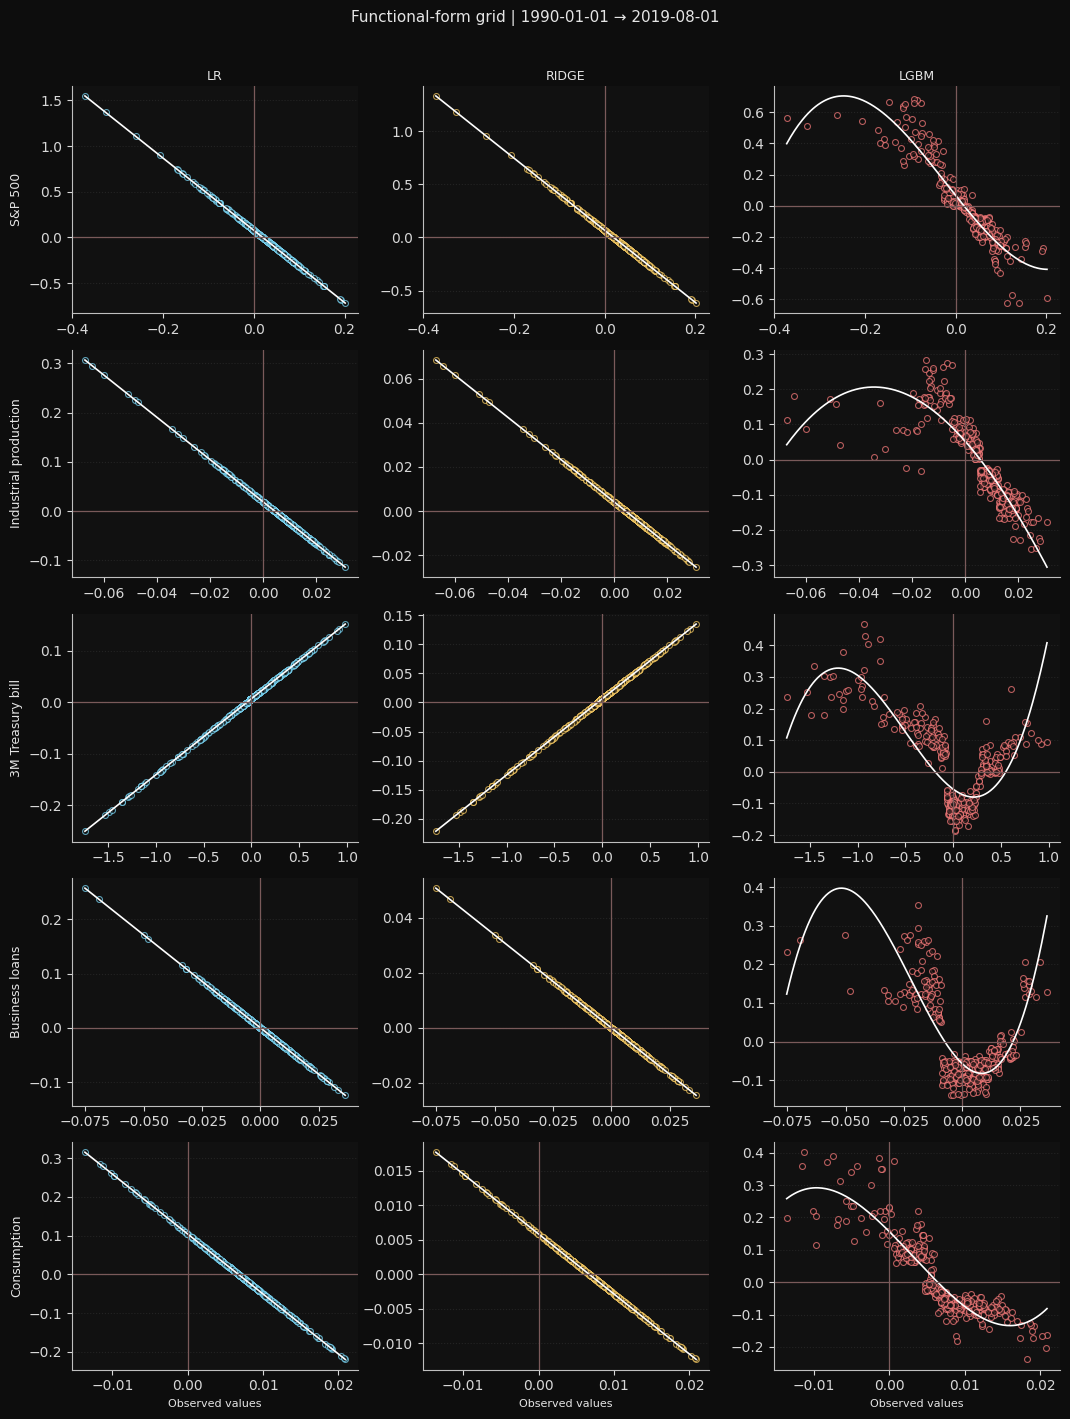

In [37]:
fig, axes = plot_functional_grid(
    models_dict=models_dict,
    X_dict=X_dict,
    selected_vars=selected_vars,
    start_date="1990-01-01",
    end_date="2019-08-01",
    date_col="ds",
    poly_deg_lgbm=3,
    figsize_per_cell=(3.6, 2.8),
    max_n=2000,
    random_state=42,
    _pretty_label_from_feat=_pretty_label_from_feat,
    use_pretty_labels=True,
)

plt.show()